In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from numba import njit
from tqdm.notebook import tqdm

In [2]:
# ORNSTEIN-UHLENBECK PARAMETERS
# Mean growth rate (hour^-1)
mu = 1.0
# Doubling time at mean growth rate: T_d = ln(2) / mu
T_d = np.log(2) / mu
# Correlation timescale: "a couple of cell doublings" ≈ 2 * T_d
tau = 2 * T_d
# Mean reversion rate: θ = 1/τ
theta = 1 / tau
# For OU process: fluctuation_scale = σ / sqrt(2θ)
# Therefore: σ = fluctuation_scale * sqrt(2θ)
fluctuation_scale = 0.2  # per hour
sigma = fluctuation_scale * np.sqrt(2 * theta)
print(f"Ornstein-Uhlenbeck parameters:")
print(f"Doubling time at μ = {mu} hour⁻¹: {T_d:.3f} hours")
print(f"τ: {tau:.3f} hours")
print(f"θ: {theta:.3f} hour⁻¹")
print(f"σ: {sigma:.3f} hour⁻¹.⁵")
T_total = 4.5 #Total time (hours)
dt = T_total / 1000  # time step (hours)
t = np.arange(0, T_total, dt)
n_points = len(t)
print(f"Δt: = {dt:.4f} hours")
print(f"Total simulation time: {T_total} hours")
print(f"Number of time points: {n_points}") 

Ornstein-Uhlenbeck parameters:
Doubling time at μ = 1.0 hour⁻¹: 0.693 hours
τ: 1.386 hours
θ: 0.721 hour⁻¹
σ: 0.240 hour⁻¹.⁵
Δt: = 0.0045 hours
Total simulation time: 4.5 hours
Number of time points: 1001


In [3]:
def simulate_g_np(n_points, mu, theta, sigma, dt, rng):
    g = np.zeros(n_points)
    g[0] = rng.normal(
        loc=mu,
        scale=sigma / np.sqrt(2 * theta)
    )
    alpha = np.exp(-theta * dt)
    beta  = sigma * np.sqrt((1 - np.exp(-2 * theta * dt)) / (2 * theta))
    
    for i in range(n_points - 1):
        mean = alpha * g[i] + (1 - alpha) * mu
        g[i + 1] = rng.normal(mean, beta)
    return g

In [4]:
rng_data = np.random.RandomState(42)

In [5]:
def generate_dataset(N_traj, n_points, dt, mu, theta, sigma, sigma_rel=0.035, A0=250.0, rng=np.random.RandomState(42)):
    alpha = np.exp(-theta * dt)
    var_g = (sigma**2 / (2 * theta)) * (1 - alpha**2)
    var_X = (sigma**2 / theta**2) * (dt - (2 / theta) * (1 - alpha) + (1 / (2 * theta)) * (1 - alpha**2))
    cov_gX = (sigma**2 / (2 * theta**2)) * (1 - alpha)**2
    cov_matrix = np.array([
        [var_g, cov_gX],
        [cov_gX, var_X]
    ])
    sigma_n = (sigma_rel * np.sqrt(2)) / dt
    target_sigma_n = sigma_n
    G_list, A_true_list, A_obs_list, Y_noisy_list = [], [], [], []
    for _ in range(N_traj):
        g = np.zeros(n_points)
        X = np.zeros(n_points)
        g[0] = rng.normal(loc=mu,scale=sigma / np.sqrt(2 * theta))
        X[0] = np.log(A0)
        vari = rng.multivariate_normal([0, 0], cov_matrix, size=n_points - 1)
        for i in range(n_points - 1):
            mean_g = g[i] * alpha + mu * (1 - alpha)
            mean_X = X[i] + mu * dt + (g[i] - mu) * (1 - alpha) / theta
            g[i+1] = mean_g + vari[i, 0]
            X[i+1] = mean_X + vari[i, 1]
        A_true = np.exp(X)
        A_obs = A_true * rng.normal(1.0, sigma_rel, size=n_points)
        Y_noisy = np.zeros(n_points)
        for i in range(1, n_points):
            Y_noisy[i] = (np.log(A_obs[i]) - np.log(A_obs[i-1])) / dt
        Y_noisy[0] = Y_noisy[1]
        G_list.append(g)
        A_true_list.append(A_true)
        A_obs_list.append(A_obs)
        Y_noisy_list.append(Y_noisy)
    print(f"Successfully generated {N_traj} exact joint trajectories.")
    print(f"Applied Area Fuzz: {sigma_rel*100:.2f}% per frame to achieve sigma_n ~ {target_sigma_n}")
    
    return G_list, A_true_list, A_obs_list, Y_noisy_list

In [35]:
G_list, A_true_list, A_obs_list, Y_noisy_list = generate_dataset(N_traj=10, n_points=n_points, dt=dt, mu=mu, theta=3.0, sigma=0.6, sigma_rel=0.0008, rng=rng_data)

Successfully generated 10 exact joint trajectories.
Applied Area Fuzz: 0.08% per frame to achieve sigma_n ~ 0.2514157444218836


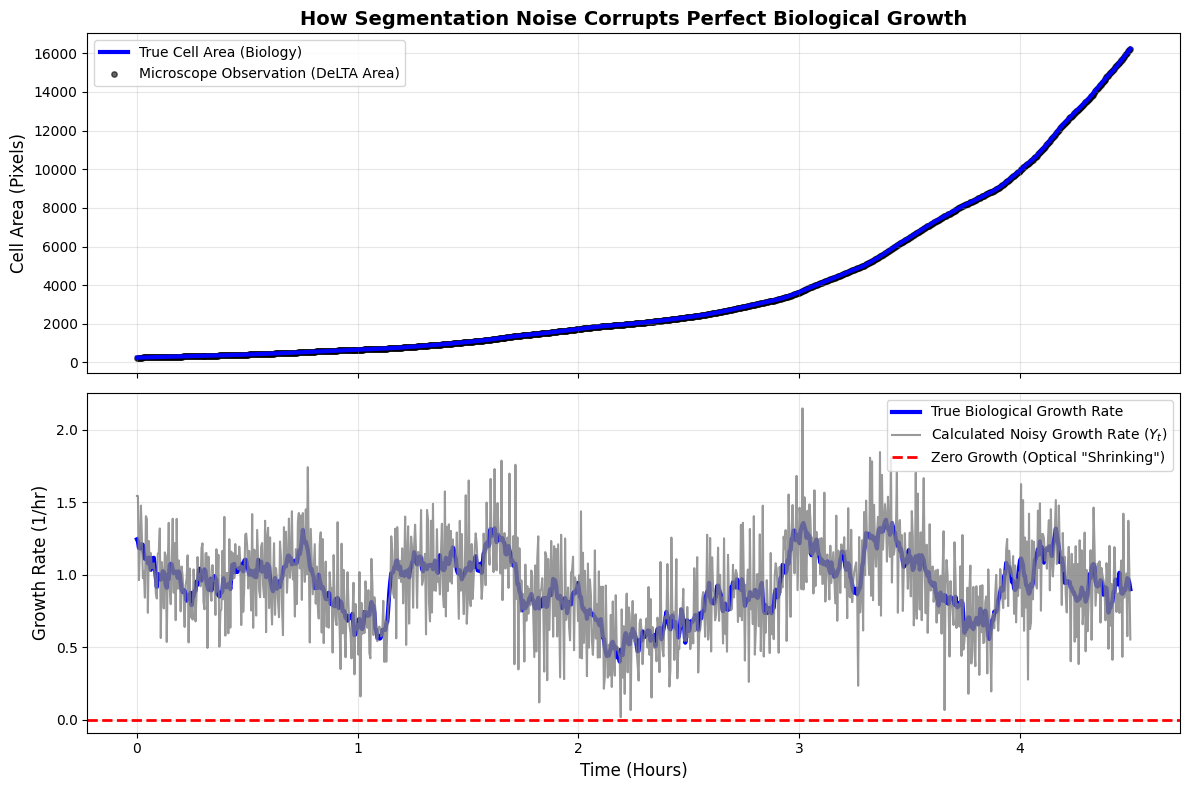

In [36]:
A_true = A_true_list[0]
A_obs = A_obs_list[0]
Y_noisy = Y_noisy_list[0]
g_true = G_list[0]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax1.plot(t, A_true, color='blue', linewidth=3, label='True Cell Area (Biology)')
ax1.scatter(t, A_obs, color='black', s=15, alpha=0.6, label=f'Microscope Observation (DeLTA Area)')
ax1.set_title("How Segmentation Noise Corrupts Perfect Biological Growth", fontsize=14, fontweight='bold')
ax1.set_ylabel("Cell Area (Pixels)", fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax2.plot(t, g_true, color='blue', linewidth=3, label='True Biological Growth Rate')
ax2.plot(t, Y_noisy, color='gray', linewidth=1.5, alpha=0.8, label='Calculated Noisy Growth Rate ($Y_t$)')
ax2.axhline(0, color='red', linestyle='--', linewidth=2, label='Zero Growth (Optical "Shrinking")')
ax2.set_xlabel("Time (Hours)", fontsize=12)
ax2.set_ylabel("Growth Rate (1/hr)", fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
def convert_area_to_log(area_data):
    if isinstance(area_data, list):
        return [np.log(A) for A in area_data]
    else:
        return np.log(area_data)

In [24]:
@njit
def Likelihood(log_A_obs, dt, mu, theta, sigma, sigma_rel):
    n_steps = len(log_A_obs)
    alpha = np.exp(-theta * dt)
    F = np.array([
        [1.0, (1.0 - alpha) / theta],  
        [0.0, alpha]            
    ])
    U = np.array([
        mu * dt - mu * (1.0 - alpha) / theta,
        mu * (1.0 - alpha)
    ])
    var_g = (sigma**2 / (2 * theta)) * (1 - alpha**2)
    var_X = (sigma**2 / theta**2) * (dt - (2 / theta) * (1 - alpha) + (1 / (2 * theta)) * (1 - alpha**2))
    cov_gX = (sigma**2 / (2 * theta**2)) * (1 - alpha)**2
    Q = np.array([
        [var_X, cov_gX],
        [cov_gX, var_g]
    ])
    R_scalar = sigma_rel**2
    z_curr = np.array([log_A_obs[0], mu]) 
    P_curr = np.array([[R_scalar, 0.0], [0.0, var_g]])
    log_likelihood = 0.0
    for t in range(1, n_steps):
        z_pred = F @ z_curr + U
        P_pred = F @ P_curr @ F.T + Q
        v_scalar = log_A_obs[t] - z_pred[0]
        S_scalar = P_pred[0, 0] + R_scalar
        log_likelihood += -0.5 * np.log(2 * np.pi) - 0.5 * np.log(S_scalar) - 0.5 * (v_scalar**2 / S_scalar)        
        K_t = P_pred[:, 0] / S_scalar   
        z_curr = z_pred + K_t * v_scalar
        P_curr = P_pred - np.outer(K_t, P_pred[0, :])
    return log_likelihood

In [25]:
def log_halfnormal_sigma_from_eta(eta, scale):
    s = np.exp(eta)
    return -0.5 * (s / scale)**2 + eta 

def logprior_phi(phi, bounds=None):
    if bounds is None:
        return 0.0
    mu, eta_theta, eta_sigma, eta_rel = phi
    if not (bounds['mu'][0] <= mu <= bounds['mu'][1]):
        return -np.inf
    if not (bounds['eta_theta'][0] <= eta_theta <= bounds['eta_theta'][1]):
        return -np.inf
    if not (bounds['eta_sigma'][0] <= eta_sigma <= bounds['eta_sigma'][1]):
        return -np.inf
    lp = 0.0
    lp += log_halfnormal_sigma_from_eta(eta_rel, scale=0.02)
    return lp

def logpost_phi(phi, log_A_obs, dt, bounds=None):
    mu, eta_theta, eta_sigma, eta_rel = phi
    lp = logprior_phi(phi, bounds=bounds)
    if not np.isfinite(lp):
        return -np.inf
    theta = np.exp(eta_theta)
    sigma = np.exp(eta_sigma)
    sigma_rel = np.exp(eta_rel)
    ll = Likelihood(log_A_obs, dt, mu, theta, sigma, sigma_rel)
    if not np.isfinite(ll):
        return -np.inf
    return ll + lp

In [26]:
def mh_samples_single(log_A_obs, dt, phi0=None, prop_scales=None, bounds=None, n_steps=30000, rng=None):
    if rng is None:
        rng = np.random.RandomState(1234567)
    if phi0 is None:
        phi0 = np.array([1.0, np.log(0.721), np.log(0.240), np.log(0.0008)], float)
    else:
        phi0 = np.array(phi0, float)
    if prop_scales is None:
        prop_scales = np.array([0.02, 0.06, 0.06, 0.06], float)
    else:
        prop_scales = np.array(prop_scales, float)
    phi = phi0.copy()
    logp = logpost_phi(phi, log_A_obs, dt, bounds=bounds) 
    chain = np.zeros((n_steps, 4))
    logp_chain = np.zeros(n_steps)
    accepts = 0
    for k in range(n_steps):
        if k % 1000 == 0:
            print(f"Step {k}/{n_steps} | Current logp: {logp:.1f}")
        chain[k] = phi
        logp_chain[k] = logp
        phi_star = phi + rng.normal(0.0, prop_scales, size=4)
        logp_star = logpost_phi(phi_star, log_A_obs, dt, bounds=bounds)
        if np.isfinite(logp_star):
            log_r = logp_star - logp
            if np.log(rng.uniform()) < log_r:
                phi, logp = phi_star, logp_star
                accepts += 1              
    acc_rate = accepts / float(n_steps)
    print(f"MCMC Finished! Acceptance Rate: {acc_rate*100:.2f}%")
    return chain, logp_chain, acc_rate

In [37]:
bounds = {"mu": (0.5, 2.0),"eta_theta": (np.log(0.4), np.log(6.0)),
          "eta_sigma": (np.log(1e-4), np.log(1.0)),"eta_rel":(np.log(0.0008), np.log(0.2)),}
prop_scales = np.array([0.02, 0.06, 0.06, 0.06], float)
phi0 = np.array([1.0, np.log(0.721), np.log(0.240), np.log(0.0008)], float) 

In [38]:
rng_mcmc = np.random.RandomState(987654321)

In [43]:
log_A_obs = convert_area_to_log(A_obs)
chain, logp_chain, acc_rate = mh_samples_single(log_A_obs, dt, phi0=phi0,prop_scales=prop_scales,bounds=bounds, n_steps=60000, rng=rng_mcmc)

Step 0/60000 | Current logp: 5209.7
Step 1000/60000 | Current logp: 5374.9
Step 2000/60000 | Current logp: 5374.4
Step 3000/60000 | Current logp: 5373.4
Step 4000/60000 | Current logp: 5373.1
Step 5000/60000 | Current logp: 5374.6
Step 6000/60000 | Current logp: 5373.9
Step 7000/60000 | Current logp: 5369.4
Step 8000/60000 | Current logp: 5374.5
Step 9000/60000 | Current logp: 5374.6
Step 10000/60000 | Current logp: 5374.0
Step 11000/60000 | Current logp: 5372.7
Step 12000/60000 | Current logp: 5371.9
Step 13000/60000 | Current logp: 5374.3
Step 14000/60000 | Current logp: 5374.6
Step 15000/60000 | Current logp: 5374.3
Step 16000/60000 | Current logp: 5374.6
Step 17000/60000 | Current logp: 5373.2
Step 18000/60000 | Current logp: 5372.5
Step 19000/60000 | Current logp: 5373.0
Step 20000/60000 | Current logp: 5372.6
Step 21000/60000 | Current logp: 5372.6
Step 22000/60000 | Current logp: 5374.6
Step 23000/60000 | Current logp: 5371.6
Step 24000/60000 | Current logp: 5374.3
Step 25000/60

In [44]:
def chain_phi_to_theta(chain):
    mu = chain[:, 0]
    theta = np.exp(chain[:, 1])
    sigma = np.exp(chain[:, 2])
    sigma_rel = np.exp(chain[:, 3])
    return mu, theta, sigma, sigma_rel
def plot_traces(chain, true_mu, true_theta, true_sigma, true_sigma_rel):
    mu, theta, sigma, sigma_rel = chain_phi_to_theta(chain)
    fig, axs = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
    axs[0].plot(mu, lw=0.5)
    axs[0].axhline(true_mu, color="black", linestyle="--", linewidth=1)
    axs[0].set_ylabel("mu")
    axs[1].plot(theta, lw=0.5)
    axs[1].axhline(true_theta, color="black", linestyle="--", linewidth=1)
    axs[1].set_ylabel("theta")
    axs[2].plot(sigma, lw=0.5)
    axs[2].axhline(true_sigma, color="black", linestyle="--", linewidth=1)
    axs[2].set_ylabel("sigma")
    axs[3].plot(sigma_rel, lw=0.5)
    axs[3].axhline(true_sigma_rel, color="black", linestyle="--", linewidth=1)
    axs[3].set_ylabel("sigma_rel")
    axs[3].set_xlabel("iteration")
    plt.tight_layout()
    plt.show() 

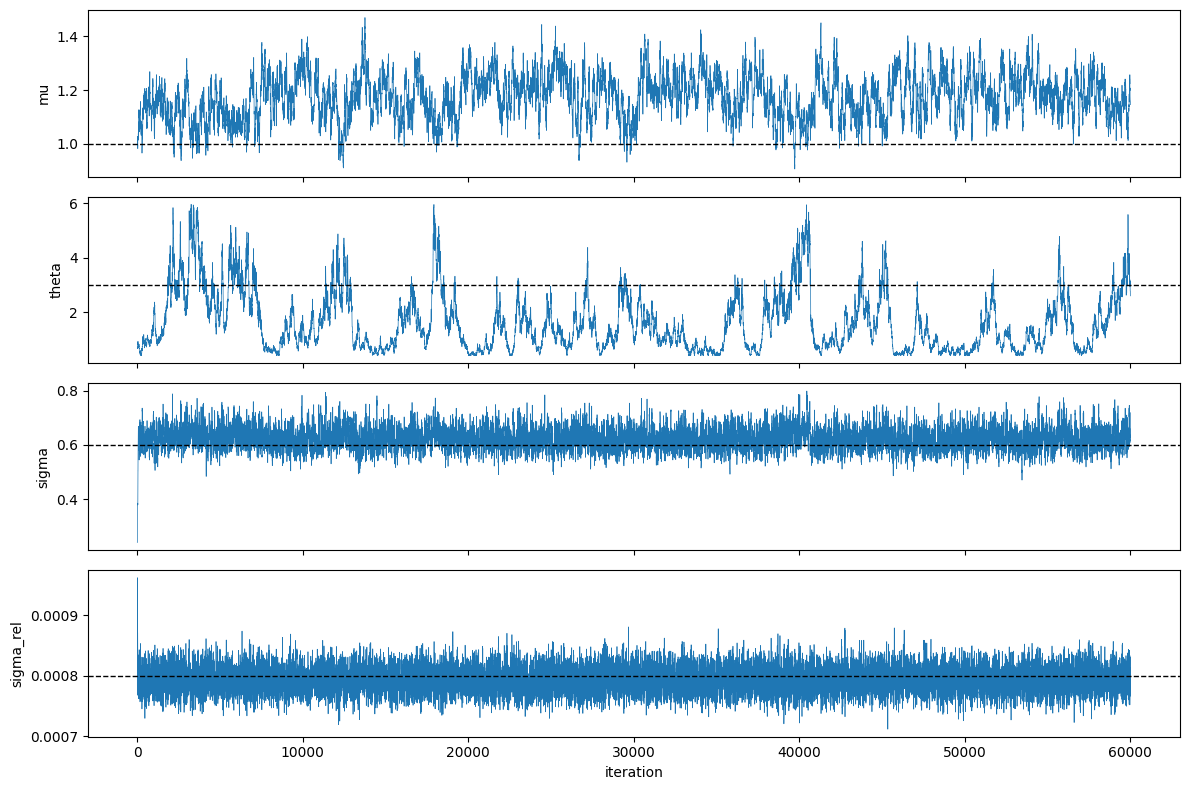

In [45]:
plot_traces(chain, true_mu=mu, true_theta=3.0, true_sigma=0.6, true_sigma_rel=0.0008)

In [46]:
def mh_samples_joint_2d(log_A_obs_list, dt, phi0=None, prop_scales=None, bounds=None, n_steps=30000, rng=None, save_filename=None):    
    if rng is None:
        rng = np.random.default_rng()
    if phi0 is None:
        phi0 = np.array([1.0, np.log(2.0), np.log(0.240), np.log(0.0006)], float)
    else:
        phi0 = np.array(phi0, float)
    if prop_scales is None:
        prop_scales = np.array([0.02, 0.06, 0.06, 0.06], float)
    else:
        prop_scales = np.array(prop_scales, float)
    def compute_joint_logp(phi_eval):
        lp = logprior_phi(phi_eval, bounds=bounds)
        if not np.isfinite(lp):
            return -np.inf
        mu, eta_theta, eta_sigma, eta_n = phi_eval
        theta = np.exp(eta_theta)
        sigma = np.exp(eta_sigma)
        sigma_rel = np.exp(eta_n)
        total_ll = 0.0
        for log_A_obs in log_A_obs_list:
            ll = Likelihood(log_A_obs, dt, mu, theta, sigma, sigma_rel)
            if not np.isfinite(ll):
                return -np.inf
            total_ll += ll
        return total_ll + lp
    phi = phi0.copy()
    logp = compute_joint_logp(phi)
    chain = np.zeros((n_steps, 4))
    logp_chain = np.zeros(n_steps)
    accepts = 0
    pbar = tqdm(range(n_steps), desc="Joint 2D MCMC")
    for k in pbar:
        if (k + 1) % 1000 == 0:
            pbar.set_postfix({'Log-P': f"{logp:.2f}"})
        chain[k] = phi
        logp_chain[k] = logp
        phi_star = phi + rng.normal(0.0, prop_scales, size=4)
        logp_star = compute_joint_logp(phi_star)
        if np.isfinite(logp_star):
            log_r = logp_star - logp
            if np.log(rng.uniform()) < log_r:
                phi, logp = phi_star, logp_star
                accepts += 1             
    acc_rate = accepts / float(n_steps)
    print(f"Finished! Acceptance rate: {acc_rate:.3f}")
    if save_filename is not None:
        np.savez(save_filename, chain=chain, logp_chain=logp_chain, acc_rate=acc_rate)
        print(f"Success! Joint MCMC data safely saved to '{save_filename}'.")
    return chain, logp_chain, acc_rate

In [47]:
log_A_obs_list = convert_area_to_log(A_obs_list)

In [48]:
bounds = {"mu": (0.5, 2.0),"eta_theta": (np.log(0.4), np.log(6.0)),
          "eta_sigma": (np.log(1e-4), np.log(1.0)),"eta_n":(np.log(0.00001), np.log(0.2)),}
prop_scales = np.array([0.02, 0.05, 0.05, 0.05], float)
phi0 = np.array([1.0, np.log(2.7), np.log(0.54), np.log(0.0008)], float) 

In [49]:
chain_multiple, logp_multiple, acc_rate_multiple = mh_samples_joint_2d(log_A_obs_list=log_A_obs_list, dt=dt, phi0=phi0, prop_scales=prop_scales, bounds=bounds, n_steps=50000, rng=rng_mcmc, save_filename="area noise Joint mcmc.npz")

Joint 2D MCMC:   0%|          | 0/50000 [00:00<?, ?it/s]

Finished! Acceptance rate: 0.081
Success! Joint MCMC data safely saved to 'area noise Joint mcmc.npz'.


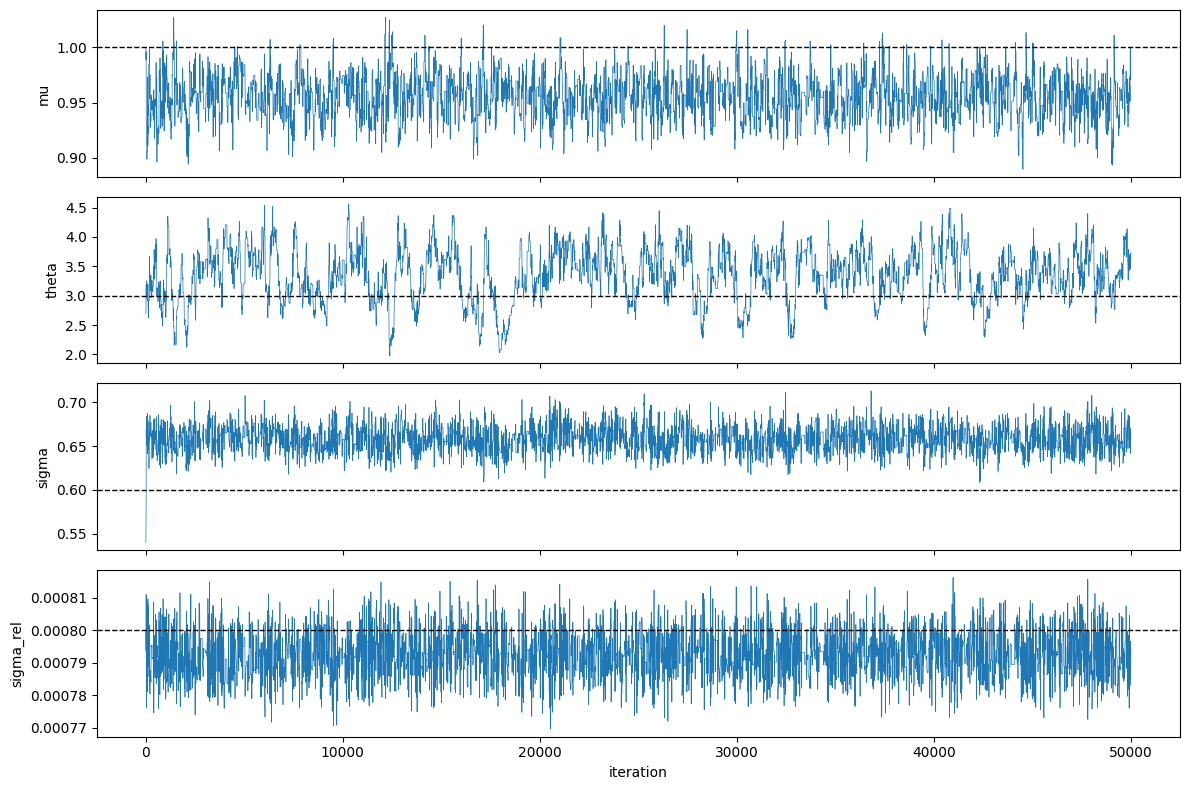

In [51]:
plot_traces(chain_multiple, true_mu=mu, true_theta=3.0, true_sigma=0.6, true_sigma_rel=0.0008)

In [52]:
G_list2, A_true_list2, A_obs_list2, Y_noisy_list2 = generate_dataset(N_traj=10, n_points=n_points, dt=dt, mu=mu, theta=0.721, sigma=0.240, sigma_rel=0.0008, rng=rng_data)

Successfully generated 10 exact joint trajectories.
Applied Area Fuzz: 0.08% per frame to achieve sigma_n ~ 0.2514157444218836


In [53]:
log_A_obs_list2 = convert_area_to_log(A_obs_list2)
chain_multiple2, logp_multiple2, acc_rate_multiple2 = mh_samples_joint_2d(log_A_obs_list=log_A_obs_list2, dt=dt, phi0=phi0, prop_scales=prop_scales, bounds=bounds, n_steps=50000, rng=rng_mcmc, save_filename="PRACTICAL PARAMETERS area noise Joint mcmc.npz")

Joint 2D MCMC:   0%|          | 0/50000 [00:00<?, ?it/s]

Finished! Acceptance rate: 0.076
Success! Joint MCMC data safely saved to 'PRACTICAL PARAMETERS area noise Joint mcmc.npz'.


In [66]:
loaded_joint_data1 = np.load("PRACTICAL PARAMETERS area noise Joint mcmc.npz")
chain_multiple2 = loaded_joint_data1['chain']

In [64]:
chain_multiple2 = chain_multiple2[-10000:]

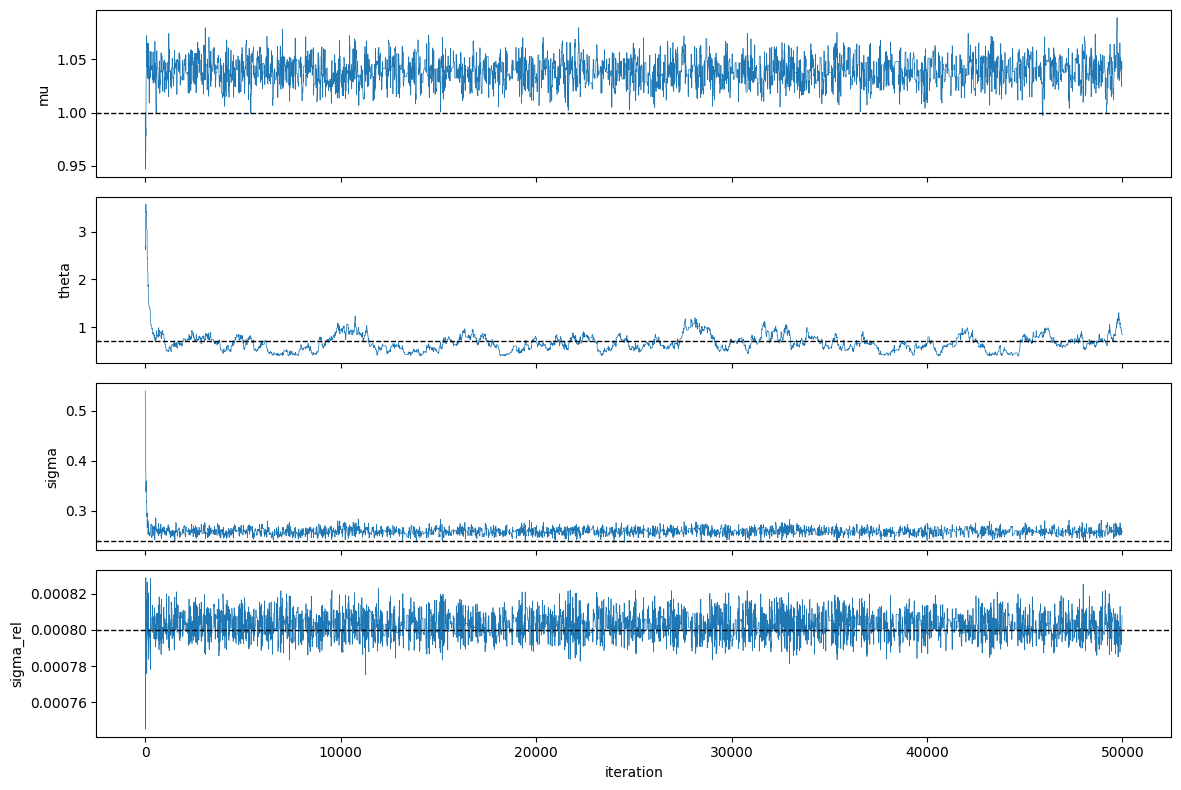

In [67]:
plot_traces(chain_multiple2, true_mu=mu, true_theta=0.721, true_sigma=0.240, true_sigma_rel=0.0008)

In [27]:
def computing_single_chains(Y, dt, phi0=None, bounds=None, prop_scales=None, n_steps=30000, rng=None, save_filename="single_mcmc_results.npz"):
    all_chains = []
    all_acc_rates = []
    all_logp_chains = [] 
    N_traj = len(Y)
    for i in tqdm(range(N_traj), desc="Computing Single Chains"):
        chain, logp_chain, acc_rate = mh_samples_single(Y[i], dt, phi0=phi0, bounds=bounds, prop_scales=prop_scales, n_steps=n_steps, rng=rng)
        all_chains.append(chain)
        all_logp_chains.append(logp_chain)
        all_acc_rates.append(acc_rate)
    all_chains_arr = np.array(all_chains)
    all_logp_chains_arr = np.array(all_logp_chains)
    all_acc_rates_arr = np.array(all_acc_rates)
    np.savez(save_filename, chain_single=all_chains_arr, logp_single=all_logp_chains_arr, acc_rate_single=all_acc_rates_arr)
    print(f"Success! {N_traj} independent MCMC chains safely saved to '{save_filename}'.")
    return all_chains_arr

In [ ]:
chain_single = computing_single_chains(log_A_obs_list, dt, phi0=phi0, bounds=bounds, prop_scales=prop_scales, n_steps=50000, rng=rng_mcmc, save_filename="2 area single_mcmc_results.npz")

In [73]:
@njit
def inv_2x2(M):
    det = M[0,0]*M[1,1] - M[0,1]*M[1,0]
    return np.array([
        [ M[1,1]/det, -M[0,1]/det],
        [-M[1,0]/det,  M[0,0]/det]
    ])
@njit
def matmul_2x2(A, B):
    return np.array([
        [A[0,0]*B[0,0] + A[0,1]*B[1,0], A[0,0]*B[0,1] + A[0,1]*B[1,1]],
        [A[1,0]*B[0,0] + A[1,1]*B[1,0], A[1,0]*B[0,1] + A[1,1]*B[1,1]]
    ])
@njit
def matvec_2x2(A, v):
    return np.array([
        A[0,0]*v[0] + A[0,1]*v[1],
        A[1,0]*v[0] + A[1,1]*v[1]
    ])
@njit
def transpose_2x2(A):
    return np.array([[A[0,0], A[1,0]], [A[0,1], A[1,1]]])
@njit
def KalmanSmoother_2D_Fast(log_A_obs, dt, mu, theta, sigma, sigma_rel):
    N = len(log_A_obs)
    alpha = np.exp(-theta * dt)
    
    F = np.array([
        [1.0, (1.0 - alpha) / theta],  
        [0.0, alpha]            
    ])
    F_T = transpose_2x2(F)
    
    U = np.array([
        mu * dt - mu * (1.0 - alpha) / theta,
        mu * (1.0 - alpha)
    ])
    
    var_g = (sigma**2 / (2 * theta)) * (1 - alpha**2)
    var_X = (sigma**2 / theta**2) * (dt - (2 / theta) * (1 - alpha) + (1 / (2 * theta)) * (1 - alpha**2))
    cov_gX = (sigma**2 / (2 * theta**2)) * (1 - alpha)**2
    Q = np.array([
        [var_X, cov_gX],
        [cov_gX, var_g]
    ])
    
    R_scalar = sigma_rel**2
    
    z_filt = np.zeros((N, 2))
    P_filt = np.zeros((N, 2, 2))
    z_pred = np.zeros((N, 2))
    P_pred = np.zeros((N, 2, 2))
    
    z_filt[0] = np.array([log_A_obs[0], mu]) 
    P_filt[0] = np.array([[R_scalar, 0.0], [0.0, var_g]])
    
    for t in range(1, N):
        z_pred[t] = matvec_2x2(F, z_filt[t-1]) + U
        P_pred[t] = matmul_2x2(matmul_2x2(F, P_filt[t-1]), F_T) + Q
        v_scalar = log_A_obs[t] - z_pred[t, 0]
        S_scalar = P_pred[t, 0, 0] + R_scalar
        
        K_t = np.array([P_pred[t, 0, 0] / S_scalar, P_pred[t, 1, 0] / S_scalar])
        
        z_filt[t] = z_pred[t] + K_t * v_scalar
        
        K_HP = np.array([
            [K_t[0]*P_pred[t, 0, 0], K_t[0]*P_pred[t, 0, 1]],
            [K_t[1]*P_pred[t, 0, 0], K_t[1]*P_pred[t, 0, 1]]
        ])
        P_filt[t] = P_pred[t] - K_HP

    z_smooth = np.zeros((N, 2))
    P_smooth = np.zeros((N, 2, 2))
    
    z_smooth[N-1] = z_filt[N-1]
    P_smooth[N-1] = P_filt[N-1]
    
    for t in range(N-2, -1, -1):
        inv_P_pred = inv_2x2(P_pred[t+1])
        C_t = matmul_2x2(matmul_2x2(P_filt[t], F_T), inv_P_pred)

        diff_z = z_smooth[t+1] - z_pred[t+1]
        z_smooth[t] = z_filt[t] + matvec_2x2(C_t, diff_z)

        diff_P = P_smooth[t+1] - P_pred[t+1]
        C_t_T = transpose_2x2(C_t)
        P_smooth[t] = P_filt[t] + matmul_2x2(matmul_2x2(C_t, diff_P), C_t_T)
        
    return z_smooth, P_smooth

In [74]:
def rts_smoother_2d(chain, log_A_obs, dt, n_samples=1000, burn_in=5000):
    N = len(log_A_obs)
    valid_chain = chain[burn_in:]
    indices = np.random.choice(len(valid_chain), size=n_samples, replace=False)
    selected_samples = valid_chain[indices]
    cloud_trajectories = np.zeros((n_samples, N))
    
    for i, phi in enumerate(selected_samples):
        mu_val = phi[0]
        theta_val = np.exp(phi[1])
        sigma_val = np.exp(phi[2])
        sigma_rel_val = np.exp(phi[3])
        z_smooth, P_smooth = KalmanSmoother_2D_Fast(
            log_A_obs, dt, mu=mu_val, theta=theta_val, sigma=sigma_val, sigma_rel=sigma_rel_val
        )
        cloud_trajectories[i, :] = z_smooth[:, 1]
    posterior_mean = np.mean(cloud_trajectories, axis=0)
    
    return posterior_mean

In [75]:
def plot_cloud_grid_joint(chain, log_A_obs_list, true_G, dt, rows, cols, n_samples=100, zoom_t_start=3.0, zoom_t_end=3.5):
    N_traj = len(log_A_obs_list)
    if rows * cols < N_traj:
        raise ValueError(f"A {rows}x{cols} grid only holds {rows*cols} plots, but you have {N_traj}.")
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4), squeeze=False)
    axes = axes.flatten()
    t = np.arange(len(log_A_obs_list[0])) * dt
    idx_start = int(zoom_t_start / dt)
    idx_end = int(zoom_t_end / dt)
    burn_in = 5000
    valid_chain = chain[burn_in:]
    indices = np.random.choice(len(valid_chain), size=n_samples, replace=False)
    selected_samples = valid_chain[indices]
    for i in tqdm(range(rows * cols), desc="Generating Joint MCMC Clouds"):
        ax = axes[i]
        if i < N_traj:
            y = log_A_obs_list[i]
            true_g = true_G[i]
            
            cloud_trajectories = np.zeros((n_samples, len(y)))
            
            for j, phi in enumerate(selected_samples):
                mu_s, eta_theta_s, eta_sigma_s, eta_rel_s = phi
                theta_s, sigma_s, sigma_rel_s = np.exp(eta_theta_s), np.exp(eta_sigma_s), np.exp(eta_rel_s)
                
                m_smooth, P_smooth = KalmanSmoother_2D_Fast(y, dt, mu_s, theta_s, sigma_s, sigma_rel_s)
                cloud_trajectories[j, :] = m_smooth[:, 1]    
            posterior_mean = np.mean(cloud_trajectories, axis=0) 
            ax.plot(t, cloud_trajectories.T, color='gray', alpha=0.1, lw=1)
            ax.plot(t, posterior_mean, color='blue', lw=2, label='Posterior Mean') 
            if true_G is not None:
                ax.plot(t, true_g, 'r--', lw=2, label='Ground Truth')
            m_g = m_smooth[:, 1]
            std_g = np.sqrt(P_smooth[:, 1, 1])
            ax.fill_between(t, m_g - 1.96*std_g, m_g + 1.96*std_g, color='blue', alpha=0.15)
            
            # FIX: Zoom Logic (Now keyed to true_g instead of the massive Log-Area y)
            g_window = true_g[idx_start:idx_end]
            g_buffer = (np.max(g_window) - np.min(g_window)) * 0.3
            ax.set_xlim(zoom_t_start, zoom_t_end)
            ax.set_ylim(np.min(g_window) - g_buffer, np.max(g_window) + g_buffer)
            ax.set_title(f"Cell {i+1}", fontweight='bold')
            ax.set_xlabel("Time (hours)")
            if i % cols == 0: ax.set_ylabel("Growth Rate")
            if i == 0:
                cloud_proxy = mlines.Line2D([], [], color='gray', alpha=0.5, label='Parameter Uncertainty Cloud')
                handles, labels = ax.get_legend_handles_labels()
                by_label = dict(zip(labels, handles))
                by_label['Parameter Uncertainty Cloud'] = cloud_proxy
                ax.legend(by_label.values(), by_label.keys(), loc='best', fontsize=8)
                
        else:
            ax.axis('off')

    plt.tight_layout()
    plt.show()

Generating Joint MCMC Clouds:   0%|          | 0/10 [00:00<?, ?it/s]

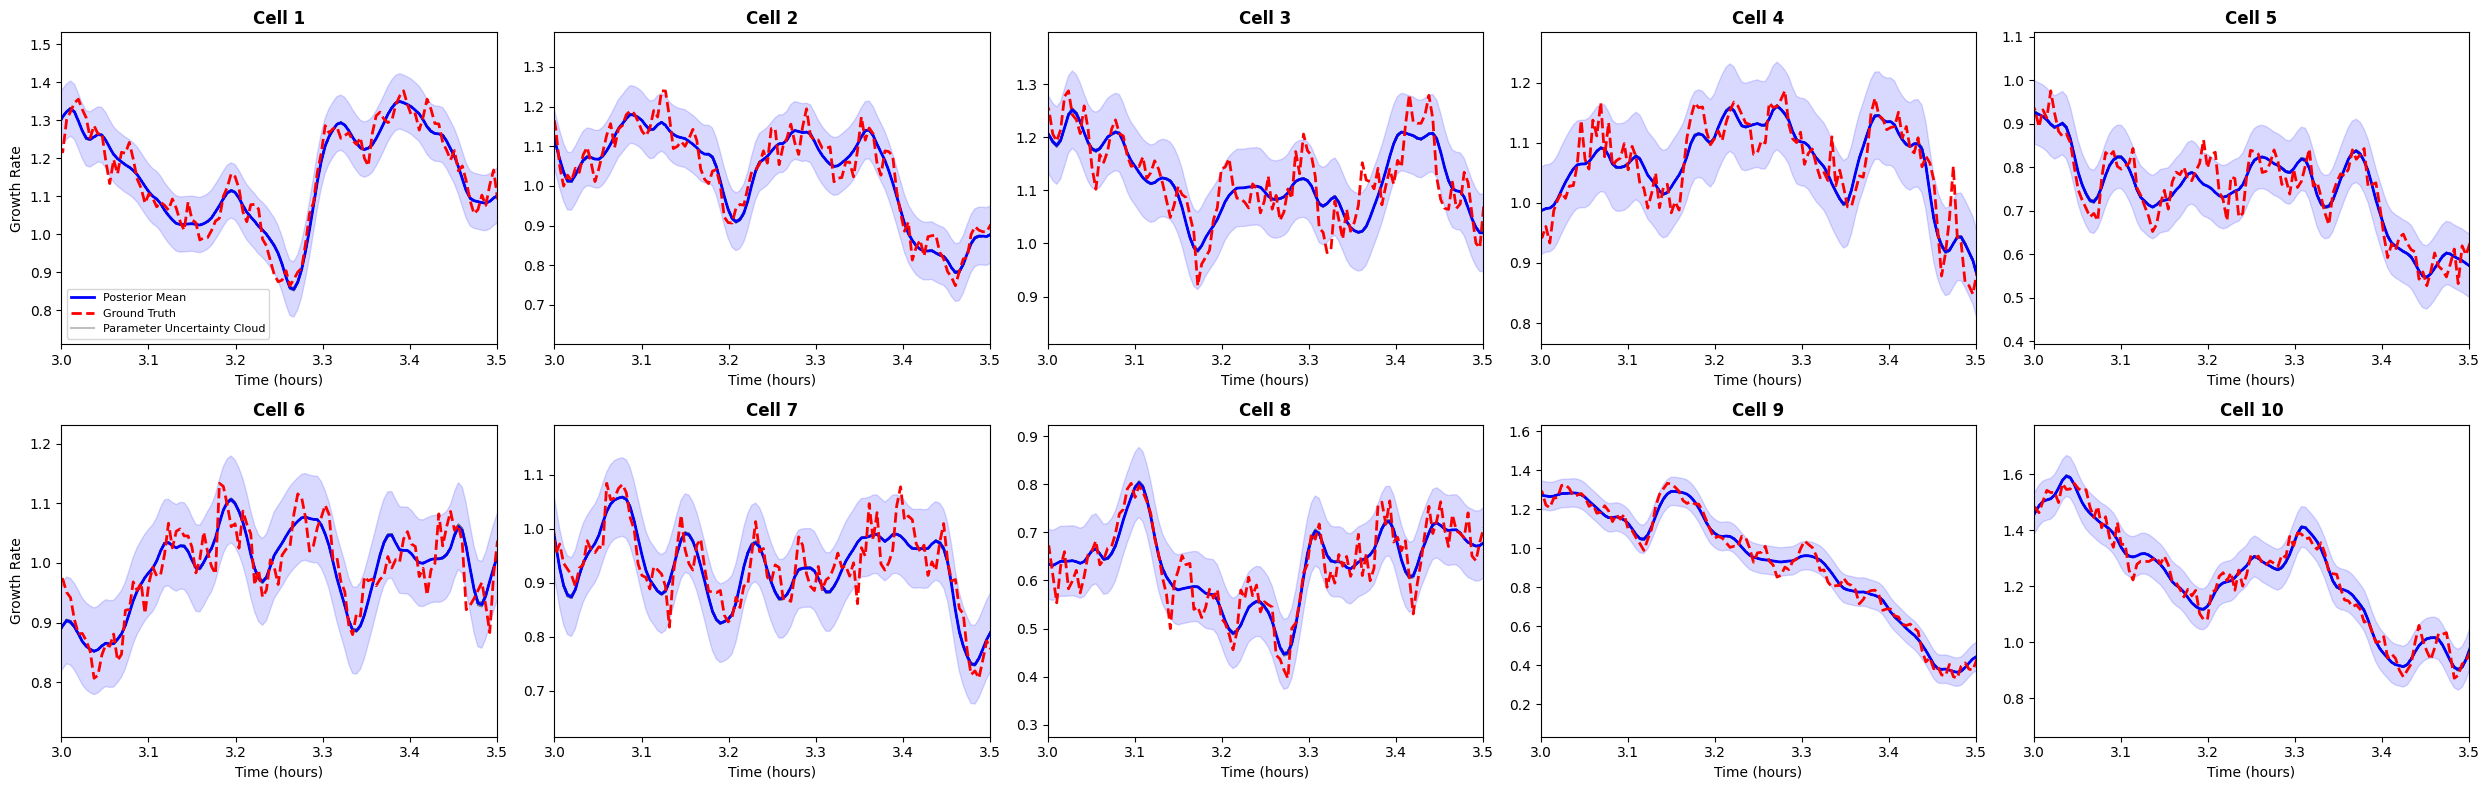

In [76]:
plot_cloud_grid_joint(chain_multiple, log_A_obs_list, true_G=G_list, dt=dt, rows=2, cols=5, n_samples=1000, zoom_t_start=3.0, zoom_t_end=3.5)

Generating Joint MCMC Clouds:   0%|          | 0/10 [00:00<?, ?it/s]

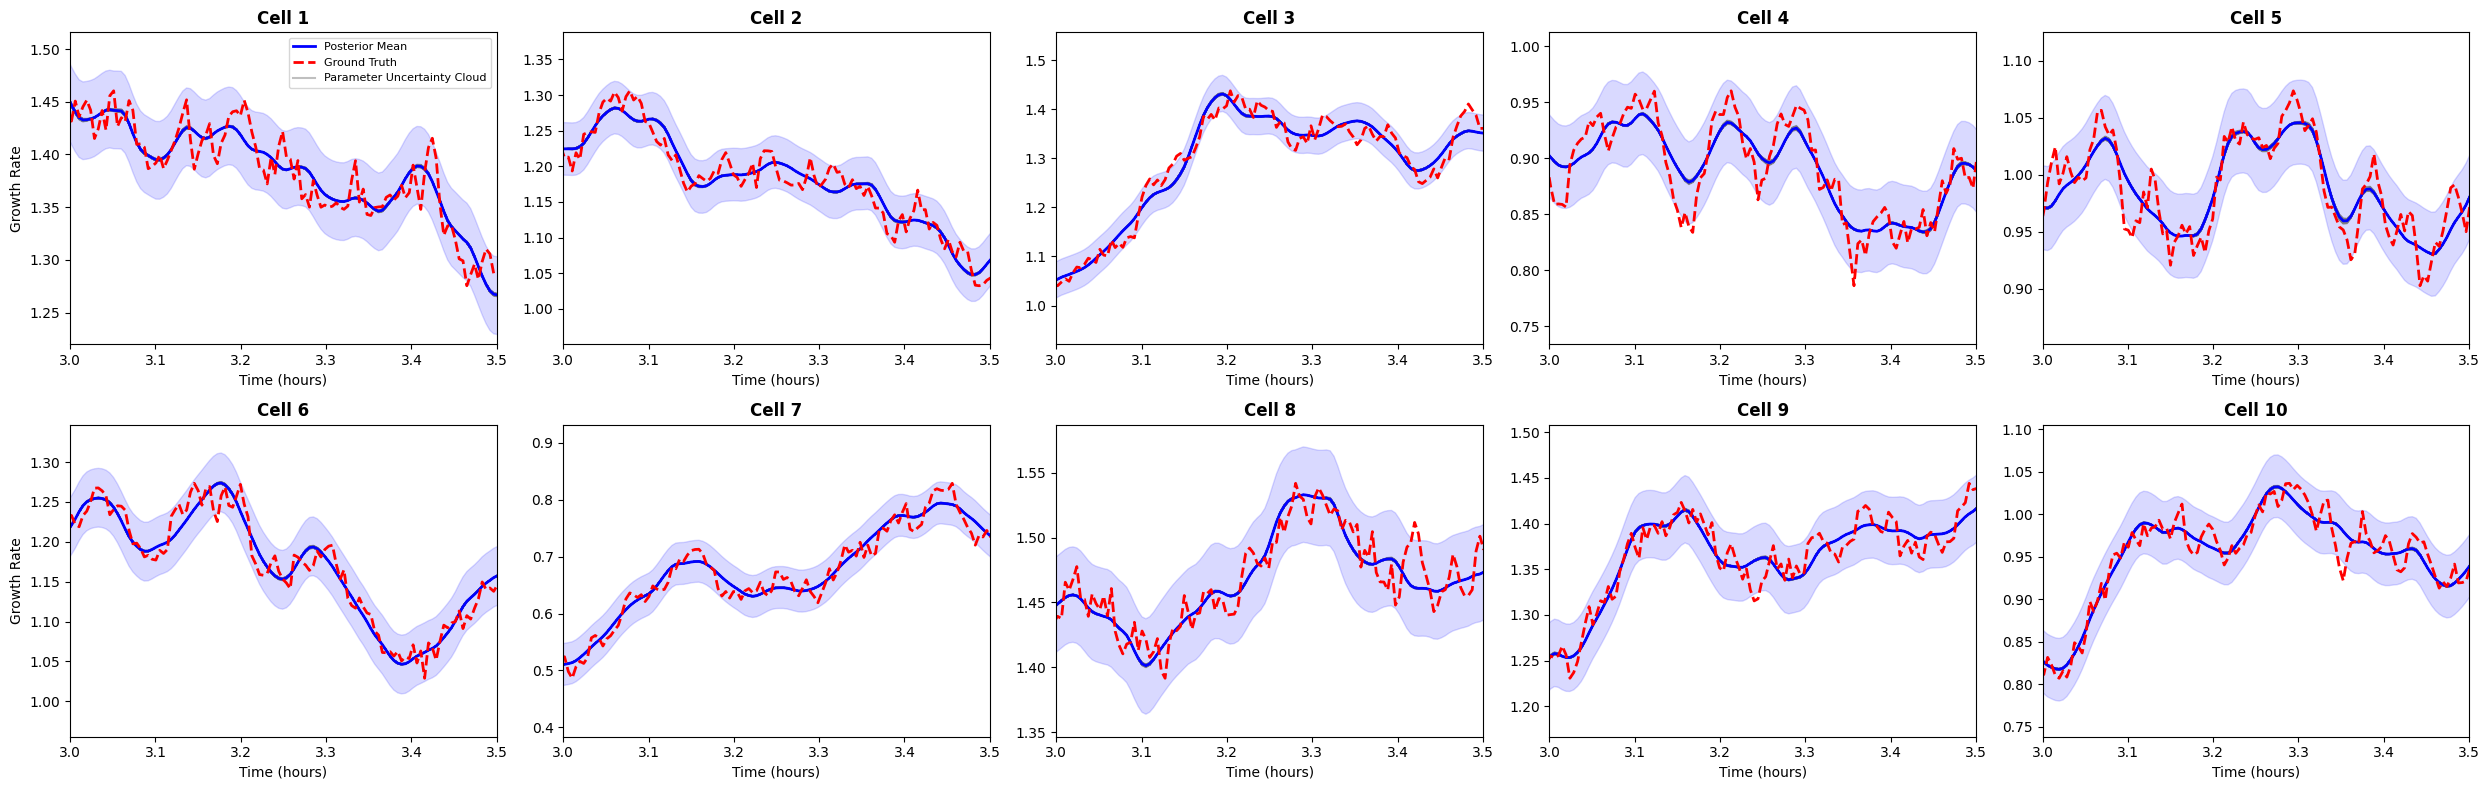

In [77]:
plot_cloud_grid_joint(chain_multiple2, log_A_obs_list2, true_G=G_list2, dt=dt, rows=2, cols=5, n_samples=1000, zoom_t_start=3.0, zoom_t_end=3.5)

In [88]:
def calculate_rmse(estimated_g, true_g):
    """Calculates the Root Mean Square Error."""
    return np.sqrt(np.mean((estimated_g - true_g)**2))
def plot_method_competition_violins(chain, log_A_obs_list, true_G, dt, true_sigma_rel = 0.0008, windows=[3, 5, 7, 15, 21, 50, 100, 1000], show_plots=True, return_results=False):
    """
    Compares Raw Derivative, Bayesian 2D Smoother, and multiple Moving Average windows.
    Plots the distribution of RMSE across all trajectories.
    """
    n_traj = len(log_A_obs_list)
    traj_length = len(log_A_obs_list[0])
    valid_windows = [w for w in windows if w < traj_length]
    if len(valid_windows) < len(windows):
        print(f"Note: Dropped windows {set(windows) - set(valid_windows)} because they exceed the {traj_length}-frame trajectory length.")
    rmse_raw = np.zeros(n_traj)
    rmse_bayes = np.zeros(n_traj)
    rmse_ma = {w: np.zeros(n_traj) for w in valid_windows}
    results_final = []
    print("Running the Smoothing Competition...")
    for i in range(n_traj):
        y = log_A_obs_list[i] 
        true_g = true_G[i]
        g_raw = np.gradient(y, dt)
        rmse_raw[i] = calculate_rmse(g_raw, true_g)
        results_final.append({'Trajectory': i, 'Method': 'Raw Derivative', 'RMSE': rmse_raw[i]})
        for w in valid_windows:
            window = np.ones(w) / w
            y_smoothed = np.convolve(y, window, mode='same')
            edge = w // 2
            if edge > 0:
                y_smoothed[:edge] = y[:edge]
                y_smoothed[-edge:] = y[-edge:]
            g_ma = np.gradient(y_smoothed, dt)
            rmse_w = calculate_rmse(g_ma, true_g)
            rmse_ma[w][i] = rmse_w
            results_final.append({"Trajectory": i, "Method": f"MA-{w}", "RMSE": rmse_w})
        g_bayes = rts_smoother_2d(chain, y, dt, n_samples=200, burn_in=5000)
        rmse_bayes[i] = calculate_rmse(g_bayes, true_g)
        results_final.append({'Trajectory': i, 'Method': 'Bayesian RTS', 'RMSE': rmse_bayes[i]})
    if show_plots:
        data_to_plot = [rmse_raw, rmse_bayes] + [rmse_ma[w] for w in valid_windows]
        labels = ['Raw\nDeriv', 'Bayesian\n2D Smoother'] + [f'MA\n({w})' for w in valid_windows] 
        fig, ax = plt.subplots(figsize=(14, 6))
        parts = ax.violinplot(data_to_plot, showmeans=True, showextrema=True)
        colors = ['lightcoral', 'dodgerblue'] + ['orange'] * len(valid_windows)
        for pc, color in zip(parts['bodies'], colors):
            pc.set_facecolor(color)
            pc.set_edgecolor('black')
            pc.set_alpha(0.7)
        for partname in ('cbars', 'cmins', 'cmaxes', 'cmeans'):
            vp = parts[partname]
            vp.set_edgecolor('black')
            vp.set_linewidth(1.5)
        theoretical_raw_rmse = true_sigma_rel / (np.sqrt(2) * dt)
        ax.axhline(theoretical_raw_rmse, color='gray', linestyle='--', alpha=0.8, label='Theoretical Raw Noise')
        ax.set_xticks(np.arange(1, len(labels) + 1))
        ax.set_xticklabels(labels, fontweight='bold', fontsize=10)
        ax.set_ylabel('Root Mean Square Error (RMSE)', fontweight='bold')
        ax.set_title('Growth Rate Estimation Accuracy\n(Comparing Bayesian Inference vs. Moving Average Spectrum)', fontweight='bold', fontsize=14)
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        print("\n--- Final Average RMSE Scores ---")
        print(f"Raw Derivative: {np.mean(rmse_raw):.4f}")
        print(f"Bayesian RTS:   {np.mean(rmse_bayes):.4f}")
        print("Moving Averages:")
        for w in valid_windows:
            print(f"  - MA (w={w}):  {np.mean(rmse_ma[w]):.4f}")
        plt.tight_layout()
        plt.show()
    if return_results:
        return results_final

Dashed line is the theoretical RMSE for the raw derivative method, calculated as sigma_rel / (sqrt(2) * dt). This represents the expected noise level in the growth rate estimates when using the raw numerical derivative, given the area measurement noise (sigma_rel) and the time step (dt).

Running the Smoothing Competition...

--- Final Average RMSE Scores ---
Raw Derivative: 0.1261
Bayesian RTS:   0.0359
Moving Averages:
  - MA (w=3):  0.0620
  - MA (w=5):  0.0459
  - MA (w=7):  0.0425
  - MA (w=15):  0.0506
  - MA (w=21):  0.0587
  - MA (w=50):  0.0938
  - MA (w=100):  0.1287


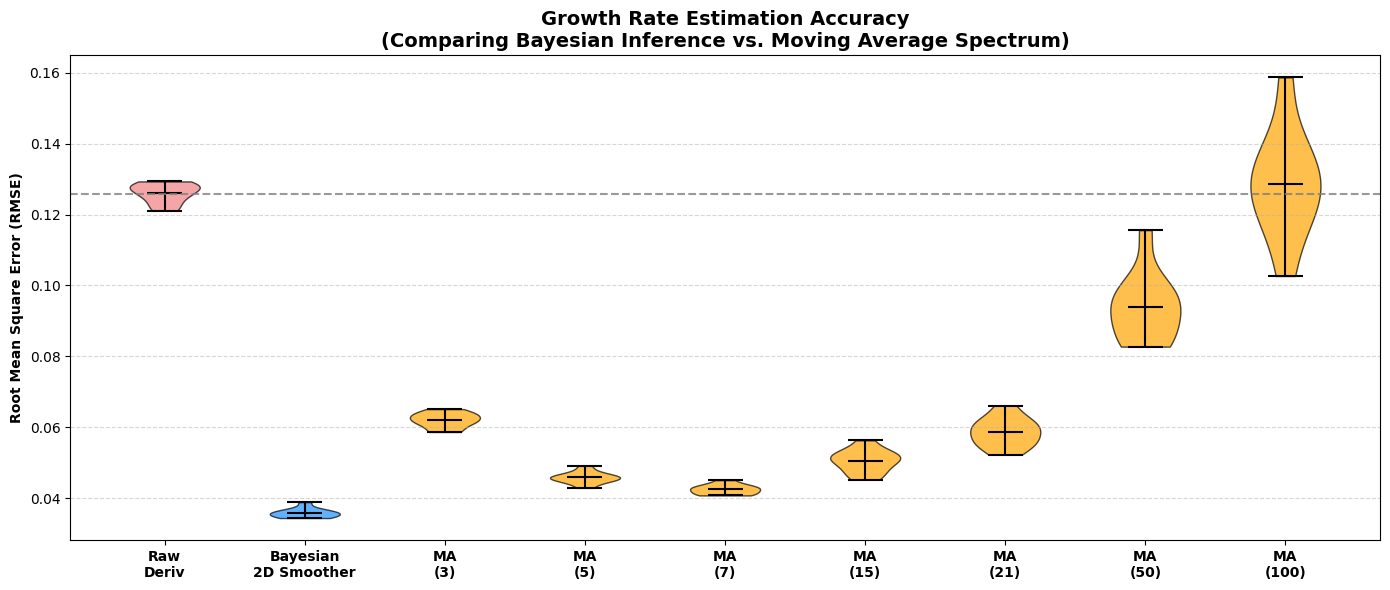

In [89]:
plot_method_competition_violins(chain_multiple, log_A_obs_list, true_G=G_list, dt=dt,true_sigma_rel=0.0008, windows=[3, 5, 7, 15, 21, 50, 100], show_plots=True, return_results=False)

Running the Smoothing Competition...

--- Final Average RMSE Scores ---
Raw Derivative: 0.1271
Bayesian RTS:   0.0184
Moving Averages:
  - MA (w=3):  0.0603
  - MA (w=5):  0.0382
  - MA (w=7):  0.0304
  - MA (w=15):  0.0265
  - MA (w=21):  0.0295
  - MA (w=50):  0.0484
  - MA (w=100):  0.0678
  - MA (w=200):  0.1241


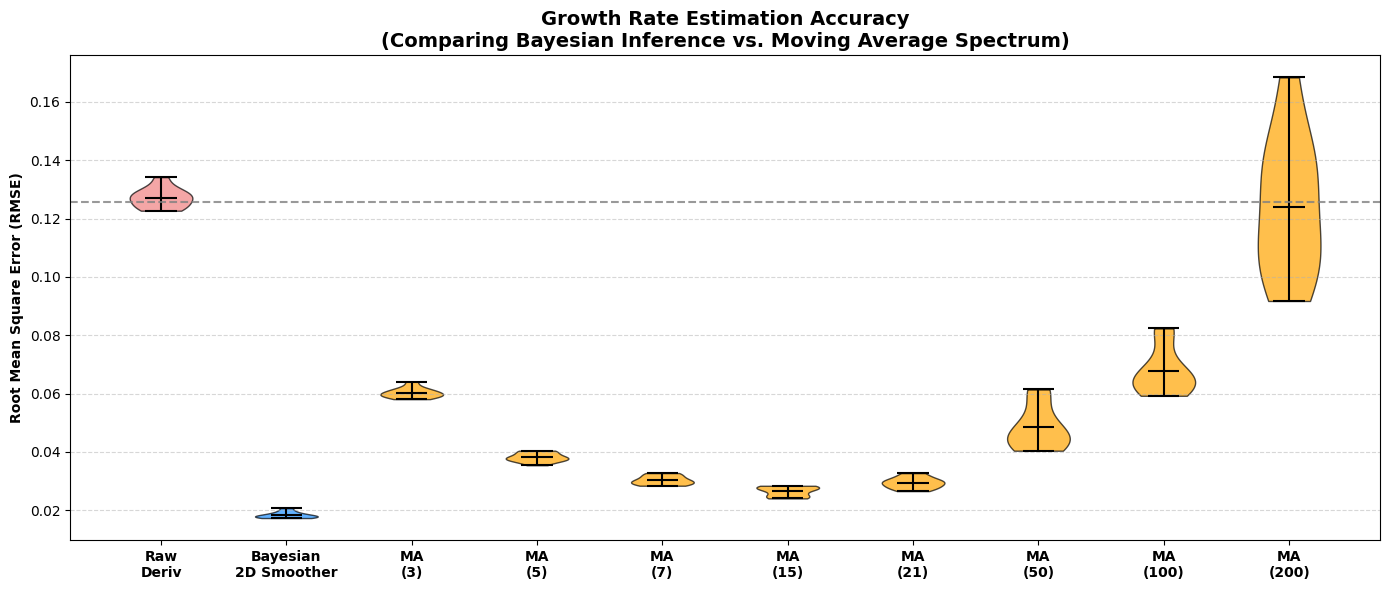

In [90]:
plot_method_competition_violins(chain_multiple2, log_A_obs_list2, true_G=G_list2, dt=dt,true_sigma_rel=0.0008, windows=[3, 5, 7, 15, 21, 50, 100, 200], show_plots=True, return_results=False)

need to apply savitzky golay filter

Running Competition across 8 MA windows. This might take a minute...

--- Final Average RMSE Scores ---
Raw Derivative: 0.1008
MA (w=  3):    0.0488
MA (w=  5):    0.0312
MA (w=  7):    0.0253
MA (w= 15):    0.0234
MA (w= 21):    0.0258
MA (w= 50):    0.0389
MA (w=100):    0.0553
MA (w=1000):    0.1009
Bayesian RTS:   0.0170  <-- THE CHAMPION


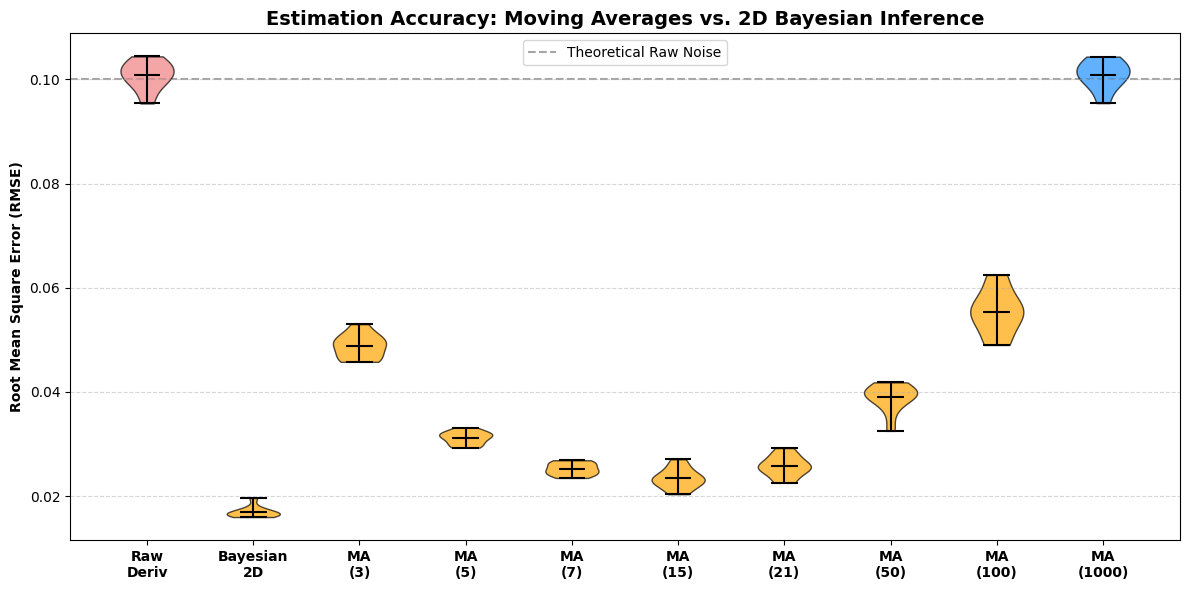

In [42]:
plot_extended_competition(chain_multiple, log_A_obs_list, true_G=G_list, dt=dt, windows=[3, 5, 7, 15, 21, 50, 100, 1000])